<a href="https://colab.research.google.com/github/Abhinav0909/Reinforcement-Learning-Based-Prediction-of-the-S-P-200-Using-Financial-and-News-Data/blob/main/Data_Mining_Latest_Code_with_proper_seeding_and_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Loading

#### Loading data from libraries once and storing it in drive for fetching(one-time process)

In [ ]:
%pip install gnews
from gnews import GNews
import re
import os
import time
import pandas as pd
from datetime import date,datetime, timedelta
# --- Configuration ---
CSV_FILE = "cleaned_stock_news_2023_2025_latest(S&P200).csv"

# Date range
START_DATE = datetime(2023, 1, 1)
END_DATE = datetime(2025,12,31)

tickers = [
    "NVDA", "AAPL", "MSFT", "AMZN", "GOOGL", "GOOG", "META", "AVGO", "TSLA", "BRK-B",
    "LLY", "WMT", "JPM", "V", "XOM", "MA", "ORCL", "COST", "HD", "PG",
    "JNJ", "NFLX", "BAC", "ABBV", "KO", "CRM", "AMD", "ADBE", "QCOM", "LIN",
    "TMUS", "INTU", "TXN", "AMGN", "DIS", "PM", "CAT", "VZ", "NEE", "LOW",
    "UNP", "IBM", "HON", "AXP", "RTX", "GS", "MS", "GE", "PLTR", "SYK",
    "TMO", "SCHW", "TJX", "VRTX", "COP", "REGN", "BSX", "ADP", "MMC", "ETN",
    "CI", "C", "CB", "MDLZ", "ELV", "GILD", "DE", "LMT", "ADI", "BA",
    "AMT", "MU", "PANW", "SBUX", "ISRG", "LRCX", "NOW", "PLD", "ZTS", "MDT",
    "GEV", "KLAC", "SNPS", "CDNS", "ICE", "CRWD", "BX", "PH", "WELL",
    "MCK", "CEG", "AJG", "WM", "APH", "ITW", "SHW", "KKR", "ORLY",
    "CVS", "ECL", "AON", "CTAS", "CL", "MCO", "MSI", "PYPL", "NKE", "WMB",
    "GD", "UPS", "DASH", "CMG", "HCA", "PNC", "USB", "HWM", "EMR", "FTNT",
    "AZO", "NOC", "JCI", "BK", "ADSK", "EOG", "TRV", "ROP", "APD", "NEM",
    "MAR", "HLT", "RCL", "CSX", "APO", "CARR", "WDAY", "ABNB", "AEP", "COIN",
    "FCX", "DHR", "SPGI", "MPC", "PSX", "VLO", "KMB", "MCHP", "TEL", "F",
    "AIG", "D", "HUM", "FDX", "EW", "IQV", "STZ", "CME", "IDXX", "KHC",
    "DXCM", "A", "PAYX", "BKR", "MSCI", "O", "MET", "PRU", "GPN", "TGT",
    "DOW", "NSC", "MNST", "WBD", "KVUE", "DVN", "HAL", "SLB", "VRSK",
    "MTD", "EXC", "ED", "PEG", "SRE", "WEC", "AWK", "KDP", "LULU",
    "CHTR", "PCAR", "DLTR", "EBAY", "KR", "ROST", "FAST", "CPRT", "KMI", "URI",
    "UNH", "CSCO", "ACN", "PEP"
]

# Map values to ticker companies
TICKER_NAMES = {
    "NVDA": "NVIDIA Corporation",
    "AAPL": "Apple Inc.",
    "MSFT": "Microsoft Corporation",
    "AMZN": "Amazon.com, Inc.",
    "GOOGL": "Alphabet Inc. (Class A)",
    "GOOG": "Alphabet Inc. (Class C)",
    "META": "Meta Platforms, Inc.",
    "AVGO": "Broadcom Inc.",
    "TSLA": "Tesla, Inc.",
    "BRK-B": "Berkshire Hathaway Inc. (Class B)",
    "LLY": "Eli Lilly and Company",
    "WMT": "Walmart Inc.",
    "JPM": "JPMorgan Chase & Co.",
    "V": "Visa Inc.",
    "XOM": "Exxon Mobil Corporation",
    "MA": "Mastercard Incorporated",
    "ORCL": "Oracle Corporation",
    "COST": "Costco Wholesale Corporation",
    "HD": "The Home Depot, Inc.",
    "PG": "Procter & Gamble Company",
    "JNJ": "Johnson & Johnson",
    "NFLX": "Netflix, Inc.",
    "BAC": "Bank of America Corporation",
    "ABBV": "AbbVie Inc.",
    "KO": "The Coca-Cola Company",
    "CRM": "Salesforce, Inc.",
    "AMD": "Advanced Micro Devices, Inc.",
    "ADBE": "Adobe Inc.",
    "QCOM": "QUALCOMM Incorporated",
    "LIN": "Linde plc",
    "TMUS": "T-Mobile US, Inc.",
    "INTU": "Intuit Inc.",
    "TXN": "Texas Instruments Incorporated",
    "AMGN": "Amgen Inc.",
    "DIS": "The Walt Disney Company",
    "PM": "Philip Morris International Inc.",
    "CAT": "Caterpillar Inc.",
    "VZ": "Verizon Communications Inc.",
    "NEE": "NextEra Energy, Inc.",
    "LOW": "Lowe's Companies, Inc.",
    "UNP": "Union Pacific Corporation",
    "IBM": "International Business Machines Corporation",
    "HON": "Honeywell International Inc.",
    "AXP": "American Express Company",
    "RTX": "RTX Corporation",
    "GS": "The Goldman Sachs Group, Inc.",
    "MS": "Morgan Stanley",
    "GE": "General Electric Company",
    "PLTR": "Palantir Technologies Inc.",
    "SYK": "Stryker Corporation",
    "TMO": "Thermo Fisher Scientific Inc.",
    "SCHW": "The Charles Schwab Corporation",
    "TJX": "The TJX Companies, Inc.",
    "VRTX": "Vertex Pharmaceuticals Incorporated",
    "COP": "ConocoPhillips",
    "REGN": "Regeneron Pharmaceuticals, Inc.",
    "BSX": "Boston Scientific Corporation",
    "ADP": "Automatic Data Processing, Inc.",
    "MMC": "Marsh & McLennan Companies, Inc.",
    "ETN": "Eaton Corporation plc",
    "CI": "The Cigna Group",
    "C": "Citigroup Inc.",
    "CB": "Chubb Limited",
    "MDLZ": "Mondelez International, Inc.",
    "ELV": "Elevance Health, Inc.",
    "GILD": "Gilead Sciences, Inc.",
    "DE": "Deere & Company",
    "LMT": "Lockheed Martin Corporation",
    "ADI": "Analog Devices, Inc.",
    "BA": "The Boeing Company",
    "AMT": "American Tower Corporation",
    "MU": "Micron Technology, Inc.",
    "PANW": "Palo Alto Networks, Inc.",
    "SBUX": "Starbucks Corporation",
    "ISRG": "Intuitive Surgical, Inc.",
    "LRCX": "Lam Research Corporation",
    "NOW": "ServiceNow, Inc.",
    "PLD": "Prologis, Inc.",
    "ZTS": "Zoetis Inc.",
    "MDT": "Medtronic plc",
    "GEV": "GE Vernova Inc.",
    "KLAC": "KLA Corporation",
    "SNPS": "Synopsys, Inc.",
    "CDNS": "Cadence Design Systems, Inc.",
    "ICE": "Intercontinental Exchange, Inc.",
    "CRWD": "CrowdStrike Holdings, Inc.",
    "BX": "Blackstone Inc.",
    "PH": "Parker-Hannifin Corporation",
    "WELL": "Welltower Inc.",
    "MCK": "McKesson Corporation",
    "CEG": "Constellation Energy Corporation",
    "AJG": "Arthur J. Gallagher & Co.",
    "WM": "Waste Management, Inc.",
    "APH": "Amphenol Corporation",
    "ITW": "Illinois Tool Works Inc.",
    "SHW": "The Sherwin-Williams Company",
    "KKR": "KKR & Co. Inc.",
    "ORLY": "O'Reilly Automotive, Inc.",
    "CVS": "CVS Health Corporation",
    "ECL": "Ecolab Inc.",
    "AON": "Aon plc",
    "CTAS": "Cintas Corporation",
    "CL": "Colgate-Palmolive Company",
    "MCO": "Moody's Corporation",
    "MSI": "Motorola Solutions, Inc.",
    "PYPL": "PayPal Holdings, Inc.",
    "NKE": "NIKE, Inc.",
    "WMB": "The Williams Companies, Inc.",
    "GD": "General Dynamics Corporation",
    "UPS": "United Parcel Service, Inc.",
    "DASH": "DoorDash, Inc.",
    "CMG": "Chipotle Mexican Grill, Inc.",
    "HCA": "HCA Healthcare, Inc.",
    "PNC": "The PNC Financial Services Group, Inc.",
    "USB": "U.S. Bancorp",
    "HWM": "Howmet Aerospace Inc.",
    "EMR": "Emerson Electric Co.",
    "FTNT": "Fortinet, Inc.",
    "AZO": "AutoZone, Inc.",
    "NOC": "Northrop Grumman Corporation",
    "JCI": "Johnson Controls International plc",
    "BK": "The Bank of New York Mellon Corporation",
    "ADSK": "Autodesk, Inc.",
    "EOG": "EOG Resources, Inc.",
    "TRV": "The Travelers Companies, Inc.",
    "ROP": "Roper Technologies, Inc.",
    "APD": "Air Products and Chemicals, Inc.",
    "NEM": "Newmont Corporation",
    "MAR": "Marriott International, Inc.",
    "HLT": "Hilton Worldwide Holdings Inc.",
    "RCL": "Royal Caribbean Group",
    "CSX": "CSX Corporation",
    "APO": "Apollo Global Management, Inc.",
    "CARR": "Carrier Global Corporation",
    "WDAY": "Workday, Inc.",
    "ABNB": "Airbnb, Inc.",
    "AEP": "American Electric Power Company, Inc.",
    "COIN": "Coinbase Global, Inc.",
    "FCX": "Freeport-McMoRan Inc.",
    "DHR": "Danaher Corporation",
    "SPGI": "S&P Global Inc.",
    "MPC": "Marathon Petroleum Corporation",
    "PSX": "Phillips 66",
    "VLO": "Valero Energy Corporation",
    "KMB": "Kimberly-Clark Corporation",
    "MCHP": "Microchip Technology Incorporated",
    "TEL": "TE Connectivity Ltd.",
    "F": "Ford Motor Company",
    "AIG": "American International Group, Inc.",
    "D": "Dominion Energy, Inc.",
    "HUM": "Humana Inc.",
    "FDX": "FedEx Corporation",
    "EW": "Edwards Lifesciences Corporation",
    "IQV": "IQVIA Holdings Inc.",
    "STZ": "Constellation Brands, Inc.",
    "CME": "CME Group Inc.",
    "IDXX": "IDEXX Laboratories, Inc.",
    "KHC": "The Kraft Heinz Company",
    "DXCM": "DexCom, Inc.",
    "A": "Agilent Technologies, Inc.",
    "PAYX": "Paychex, Inc.",
    "BKR": "Baker Hughes Company",
    "MSCI": "MSCI Inc.",
    "O": "Realty Income Corporation",
    "MET": "MetLife, Inc.",
    "PRU": "Prudential Financial, Inc.",
    "GPN": "Global Payments Inc.",
    "TGT": "Target Corporation",
    "DOW": "Dow Inc.",
    "NSC": "Norfolk Southern Corporation",
    "MNST": "Monster Beverage Corporation",
    "WBD": "Warner Bros. Discovery, Inc.",
    "KVUE": "Kenvue Inc.",
    "DVN": "Devon Energy Corporation",
    "HAL": "Halliburton Company",
    "SLB": "Schlumberger Limited",
    "VRSK": "Verisk Analytics, Inc.",
    "MTD": "Mettler-Toledo International Inc.",
    "EXC": "Exelon Corporation",
    "ED": "Consolidated Edison, Inc.",
    "PEG": "Public Service Enterprise Group Incorporated",
    "SRE": "Sempra",
    "WEC": "WEC Energy Group, Inc.",
    "AWK": "American Water Works Company, Inc.",
    "KDP": "Keurig Dr Pepper Inc.",
    "LULU": "Lululemon Athletica Inc.",
    "CHTR": "Charter Communications, Inc.",
    "PCAR": "PACCAR Inc",
    "DLTR": "Dollar Tree, Inc.",
    "EBAY": "eBay Inc.",
    "KR": "The Kroger Co.",
    "ROST": "Ross Stores, Inc.",
    "FAST": "Fastenal Company",
    "CPRT": "Copart, Inc.",
    "KMI": "Kinder Morgan, Inc.",
    "URI": "United Rentals, Inc.",
    "UNH": "UnitedHealth Group Inc.",
    "CSCO": "Cisco Systems, Inc.",
    "ACN": "Accenture plc",
    "PEP": "PepsiCo, Inc."
}

# Junk keywords to filter out automated/low-quality content
JUNK_KEYWORDS = [
    "overbought", "oversold", "form 4", "insider buy", "insider sell",
    "filing", "sec filing", "nasdaq:", "nyse:", "earnings call transcript",
    "stock alert", "stock pick", "buy now", "top stocks", "click here",
    "subscribe", "sign up", "newsletter", "advertisement", "sponsored",
    "price target", "technical analysis", "moved up", "moved down",
    "unusual options", "options activity", "short interest", "stock screener",
    "benzinga", "marketbeat", "tipranks", "stock rover"
]

# Minimum word count for meaningful content
MIN_WORD_COUNT = 15

# --- Helper Functions ---

def scrub_text(text):
    """Clean the text of URLs, HTML tags, and messy whitespace."""
    if not text:
        return ""
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"&\w+;", "", text)
    text = re.sub(r"<[^>]+>", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def is_quality_content(text):
    """Filter out junk content and short tweets."""
    if not text:
        return False

    # Check minimum word count
    word_count = len(text.split())
    if word_count < MIN_WORD_COUNT:
        return False

    # Check for junk keywords
    text_lower = text.lower()
    if any(keyword in text_lower for keyword in JUNK_KEYWORDS):
        return False

    return True

def split_date_range(start_date, end_date, months_per_chunk=3):
    """Split date range into smaller chunks to bypass 100-article limit."""
    chunks = []
    current = start_date

    while current < end_date:
        chunk_end = min(current + timedelta(days=months_per_chunk * 30), end_date)
        chunks.append((current, chunk_end))
        current = chunk_end + timedelta(days=1)

    return chunks

def fetch_news_gnews(ticker, company_name, start_date, end_date):
    """Fetch news using GNews with chunked date ranges to get more articles."""
    all_news = []

    # Split into 3-month chunks to get more than 100 articles
    date_chunks = split_date_range(start_date, end_date, months_per_chunk=3)

    for chunk_start, chunk_end in date_chunks:
        try:
            google_news = GNews(
                language='en',
                country='US',
                start_date=(chunk_start.year, chunk_start.month, chunk_start.day),
                end_date=(chunk_end.year, chunk_end.month, chunk_end.day),
                max_results=100  # Max per chunk
            )

            # Search using both ticker and company name
            search_query = f"{ticker} OR {company_name} stock"
            news = google_news.get_news(search_query)

            if news:
                all_news.extend(news)
                print(f"    -> Found {len(news)} articles for {chunk_start.date()} to {chunk_end.date()}")

            time.sleep(0.5)  # Small delay between chunks

        except Exception as e:
            print(f"    -> Error for chunk {chunk_start.date()}: {e}")
            continue

    return all_news

# --- Main Logic ---

def main():
    final_data = []

    print("Starting Google News scraper with chunked date ranges...")
    print(f"Date range: {START_DATE.date()} to {END_DATE.date()}")
    print("Splitting into 3-month chunks to get MORE than 100 articles per ticker")
    print(f"Filters: Minimum {MIN_WORD_COUNT} words, removing junk keywords\n")
    print("Note: Make sure 'gnews' is installed: pip install gnews\n")

    for ticker in tickers:
        company_name = TICKER_NAMES.get(ticker, ticker)
        print(f"\nProcessing {ticker} ({company_name})...")

        news_items = fetch_news_gnews(ticker, company_name, START_DATE, END_DATE)
        count = 0

        for item in news_items:
            # Get published date
            pub_date = item.get("published date", "")

            # Get title and description
            title = item.get("title", "")
            description = item.get("description", "")

            # Combine title and description
            text = f"{title}. {description}" if description else title

            cleaned_text = scrub_text(text)

            # Apply quality filters
            if is_quality_content(cleaned_text):
                final_data.append({
                    "date": pub_date,
                    "tweet": cleaned_text,
                    "stock name": ticker,
                    "company name": company_name
                })
                count += 1

        print(f"  -> Total saved: {count} records")

    # Export to CSV
    if final_data:
        df = pd.DataFrame(final_data)
        df = df[["date", "tweet", "stock name", "company name"]]

        # Remove duplicates based on tweet content
        df = df.drop_duplicates(subset=["tweet"])

        # Sort by date
        df = df.sort_values("date")

        df.to_csv(CSV_FILE, index=False)
        print(f"\nSUCCESS: {len(df)} unique records saved to {CSV_FILE}")
        print(f"\nBreakdown by ticker:")
        ticker_counts = df["stock name"].value_counts().sort_index()
        for ticker, count in ticker_counts.items():
            print(f"  {ticker}: {count} articles")
        print(f"\nTotal unique articles: {len(df)}")
    else:
        print("\n No data found. Make sure 'gnews' is installed: pip install gnews")

if __name__ == "__main__":
    main()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 20.8 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=768319aa4efa384c8ca4d12b16c13cfce116ba3e77d62bf7b163e7e1f1627a10
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k
Starting Google News scraper with chunked date ranges...
Date range: 2023-01-01 to 2025-12-31
Splitting into 3-month chunks to get MORE than 100 articles per ticker
Filters: Minimum 15 words, removing junk keywords

Note: Make sure 'gnews' is installed: pip install gnews


Processing NVDA (NVIDIA Corporation)...
    -> Found 24 articles for 2023-01-01 to 2023-04-01
    -> Found 56 articles for 2023-04-02 to 2023-07-01
    -> Found 45 articles for 2023-07-02 to 2023-09-30
    -> Found 55 articles for 2023

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import date,datetime, timedelta
tickers = [
    "NVDA", "AAPL", "MSFT", "AMZN", "GOOGL", "GOOG", "META", "AVGO", "TSLA", "BRK-B",
    "LLY", "WMT", "JPM", "V", "XOM", "MA", "ORCL", "COST", "HD", "PG",
    "JNJ", "NFLX", "BAC", "ABBV", "KO", "CRM", "AMD", "ADBE", "QCOM", "LIN",
    "TMUS", "INTU", "TXN", "AMGN", "DIS", "PM", "CAT", "VZ", "NEE", "LOW",
    "UNP", "IBM", "HON", "AXP", "RTX", "GS", "MS", "GE", "PLTR", "SYK",
    "TMO", "SCHW", "TJX", "VRTX", "COP", "REGN", "BSX", "ADP", "MMC", "ETN",
    "CI", "C", "CB", "MDLZ", "ELV", "GILD", "DE", "LMT", "ADI", "BA",
    "AMT", "MU", "PANW", "SBUX", "ISRG", "LRCX", "NOW", "PLD", "ZTS", "MDT",
    "GEV", "KLAC", "SNPS", "CDNS", "ICE", "CRWD", "BX", "PH", "WELL",
    "MCK", "CEG", "AJG", "WM", "APH", "ITW", "SHW", "KKR", "ORLY",
    "CVS", "ECL", "AON", "CTAS", "CL", "MCO", "MSI", "PYPL", "NKE", "WMB",
    "GD", "UPS", "DASH", "CMG", "HCA", "PNC", "USB", "HWM", "EMR", "FTNT",
    "AZO", "NOC", "JCI", "BK", "ADSK", "EOG", "TRV", "ROP", "APD", "NEM",
    "MAR", "HLT", "RCL", "CSX", "APO", "CARR", "WDAY", "ABNB", "AEP", "COIN",
    "FCX", "DHR", "SPGI", "MPC", "PSX", "VLO", "KMB", "MCHP", "TEL", "F",
    "AIG", "D", "HUM", "FDX", "EW", "IQV", "STZ", "CME", "IDXX", "KHC",
    "DXCM", "A", "PAYX", "BKR", "MSCI", "O", "MET", "PRU", "GPN", "TGT",
    "DOW", "NSC", "MNST", "WBD", "KVUE","DVN", "HAL", "SLB", "VRSK",
    "MTD", "EXC", "ED", "PEG", "SRE", "WEC", "AWK", "KDP", "LULU",
    "CHTR", "PCAR", "DLTR", "EBAY", "KR", "ROST", "FAST", "CPRT", "KMI", "URI",
    "UNH", "CSCO", "ACN", "PEP"
]
all_ticker_data = []
for ticker in tickers:
    print(f"Downloading data for {ticker}...")
    data = yf.download(ticker, start="2023-01-01", end="2025-12-31",
                       auto_adjust=False, progress=False)

    if not data.empty:
        stock_info = yf.Ticker(ticker)
        sector = stock_info.info.get('sector', 'Unknown')
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        data = data.reset_index()
        data['Stock Name'] = ticker
        data['Sector'] = sector

        print(f"  Columns: {data.columns.tolist()}")
        all_ticker_data.append(data)
    else:
        print(f"No data found for {ticker}")

df_flat = pd.concat(all_ticker_data, ignore_index=True)

df_flat = df_flat[['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Stock Name', 'Sector']]
print(f"Shape: {df_flat.shape}")
print("\nFirst few rows:")
print(df_flat.head())

## Export to CSV
df_flat.to_csv('stock_data_latest(S&P200).csv', index=False)


### Fetch the files directly from drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df_news = pd.read_csv('/content/drive/MyDrive/Reinforcement Learning-Based Prediction of the S&P 200 Using Financial and News Data/cleaned_stock_news_2023_2025_latest(S&P200).csv')
df_news['date'] = pd.to_datetime(df_news['date']).dt.strftime('%d/%m/%Y')
df_news.columns = df_news.columns.str.title()
df_news.head()

,Date,Tweet,Stock Name,Company Name
0,01/08/2025,5 Best Dividend Stocks To Buy For August 2025 ...,PNC,"The PNC Financial Services Group, Inc."
1,01/08/2025,"Waste Management, Inc. (WM)’s CEO Is Doing A “...",WM,"Waste Management, Inc."
2,01/08/2025,"FedEx Corporation (FDX)’s CEO Is A “Hitter,” S...",FDX,FedEx Corporation
3,01/08/2025,"Exxon, Chevron Surpass Estimates With Record O...",XOM,Exxon Mobil Corporation
4,01/08/2025,KLA Corp (KLAC) Q4 2025 Earnings Call Highligh...,KLAC,KLA Corporation


In [ ]:
df_news.columns

Index(['Date', 'Tweet', 'Stock Name', 'Company Name'], dtype='object')

In [ ]:
df_news.shape

(71726, 4)

In [ ]:
df_stock = pd.read_csv('/content/drive/MyDrive/Reinforcement Learning-Based Prediction of the S&P 200 Using Financial and News Data/stock_data_latest(S&P200).csv')
df_stock['Date'] = pd.to_datetime(df_stock['Date']).dt.strftime('%d/%m/%Y')
df_stock.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name,Sector
0,03/01/2023,14.851,14.996,14.096,14.315,14.300683,401277000,NVDA,Technology
1,04/01/2023,14.567,14.853,14.241,14.749,14.734249,431324000,NVDA,Technology
2,05/01/2023,14.491,14.564,14.148,14.265,14.250736,389168000,NVDA,Technology
3,06/01/2023,14.474,15.010,14.034,14.859,14.844140,405044000,NVDA,Technology
4,09/01/2023,15.284,16.056,15.141,15.628,15.612371,504231000,NVDA,Technology


In [ ]:
df_stock.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Stock Name', 'Sector'],
      dtype='object')

In [ ]:
df_stock.shape

(149807, 9)

### EDA

#### EDA on Financial News Data

In [ ]:
# Rupam needs to add code

### Create Embeddings from tweet column by Finbert transformer

In [ ]:
%pip install --upgrade transformers sentence-transformers tqdm -q

import torch
import numpy as np
from transformers import BertTokenizer, BertModel
from tqdm.notebook import tqdm

# ── Device setup ──────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Load model ────────────────────────────────────────────────
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-tone')
model     = BertModel.from_pretrained('yiyanghkust/finbert-tone')
model.to(device)
model.eval()
print("Model loaded successfully")

# ── Mean pooling helper ───────────────────────────────────────
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state          # (batch, seq, hidden)
    mask_expanded    = attention_mask.unsqueeze(-1).float()    # (batch, seq, 1)
    sum_embeddings   = torch.sum(token_embeddings * mask_expanded, dim=1)
    sum_mask         = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask                           # (batch, hidden)

# ── Embedding function ────────────────────────────────────────
def get_embeddings(texts, batch_size=64):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
        batch = texts[i : i + batch_size]

        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            output = model(**encoded)

        # Proper mean-pool (ignores padding tokens)
        embeddings = mean_pooling(output, encoded['attention_mask'])

        # L2-normalise → cosine similarity becomes dot product
        embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)

        all_embeddings.append(embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

# ── Run ───────────────────────────────────────────────────────
sentences  = df_news['Tweet'].tolist()
print(f"Encoding {len(sentences):,} tweets...")

embeddings = get_embeddings(sentences, batch_size=64)

df_news['Embeddings'] = list(embeddings)

# ── Verify ────────────────────────────────────────────────────
print(f"\nDone!")
print(f"Embedding matrix shape : {embeddings.shape}")
print(f"Sample embedding (first 5 dims): {embeddings[0][:5]}")
print(f"df_news shape          : {df_news.shape}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 43.3 MB/s eta 0:00:00
Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: yiyanghkust/finbert-tone
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully
Encoding 71,726 tweets...


Encoding:   0%|          | 0/1121 [00:00<?, ?it/s]


Done!
Embedding matrix shape : (71726, 768)
Sample embedding (first 5 dims): [-5.0920433e-05 -4.4484939e-02 -1.5206990e-03  7.9208175e-03
  7.2789975e-02]
df_news shape          : (71726, 5)


In [ ]:
df_news.head()

,Date,Tweet,Stock Name,Company Name,Embeddings
0,01/08/2025,5 Best Dividend Stocks To Buy For August 2025 ...,PNC,"The PNC Financial Services Group, Inc.","[-5.0920433e-05, -0.04448494, -0.001520699, 0...."
1,01/08/2025,"Waste Management, Inc. (WM)’s CEO Is Doing A “...",WM,"Waste Management, Inc.","[-0.009468835, -0.045025613, -0.014149481, -0...."
2,01/08/2025,"FedEx Corporation (FDX)’s CEO Is A “Hitter,” S...",FDX,FedEx Corporation,"[-0.022724079, -0.036048323, -0.010419616, 0.0..."
3,01/08/2025,"Exxon, Chevron Surpass Estimates With Record O...",XOM,Exxon Mobil Corporation,"[-0.011347536, -0.042125393, 0.015024937, -0.0..."
4,01/08/2025,KLA Corp (KLAC) Q4 2025 Earnings Call Highligh...,KLAC,KLA Corporation,"[0.025778862, -0.071486175, 0.016954936, -0.02..."


#### EDA on Stocks data

###### Check null values in Stocks data

In [ ]:
df_stock.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Stock Name,0
Sector,0


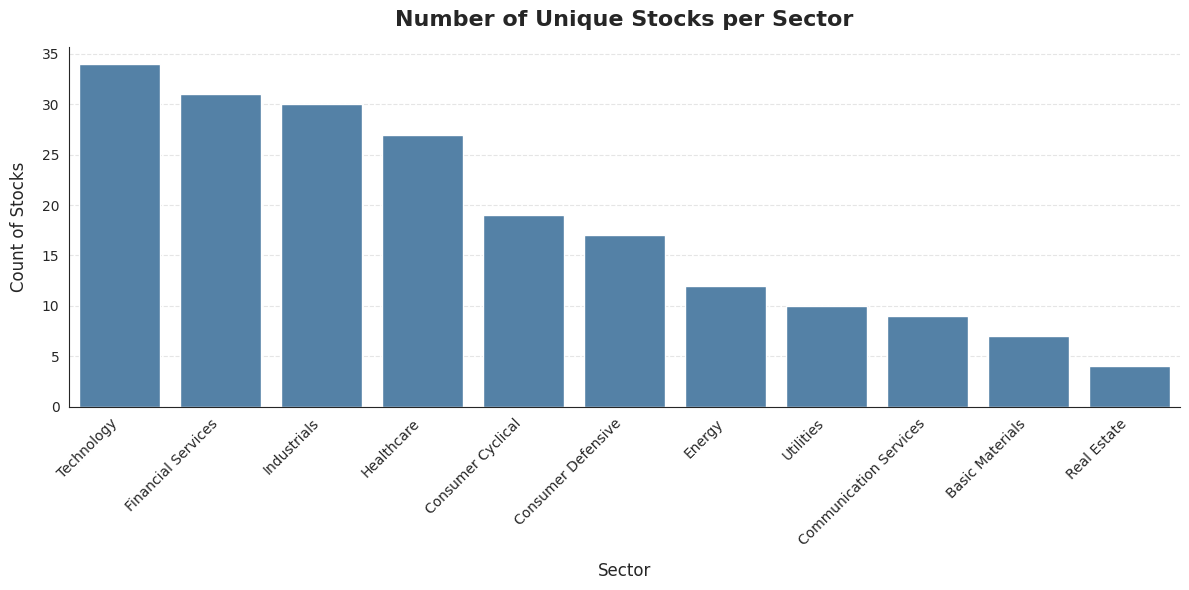

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Sector and count unique stock names
sector_counts = df_stock.groupby('Sector')['Stock Name'].nunique().sort_values(ascending=False)

# Set a clean, simple background style
sns.set_style("white")

# Plotting
plt.figure(figsize=(12, 6))

# Use a single, elegant color (e.g., 'steelblue' or 'slategray') instead of a palette
sns.barplot(x=sector_counts.index, y=sector_counts.values, color='steelblue')

# Formatting with adjusted padding and font weights
plt.title('Number of Unique Stocks per Sector', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Sector', fontsize=12, labelpad=10)
plt.ylabel('Count of Stocks', fontsize=12, labelpad=10)

# Align the rotated labels to the right so they look neat and don't overlap
plt.xticks(rotation=45, ha='right')

# Remove the top and right borders (spines) for a modern, uncluttered look
sns.despine()

# Add a very subtle horizontal grid to help read the values easily
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Automatically adjust the layout so labels don't get cut off at the bottom
plt.tight_layout()

plt.show()

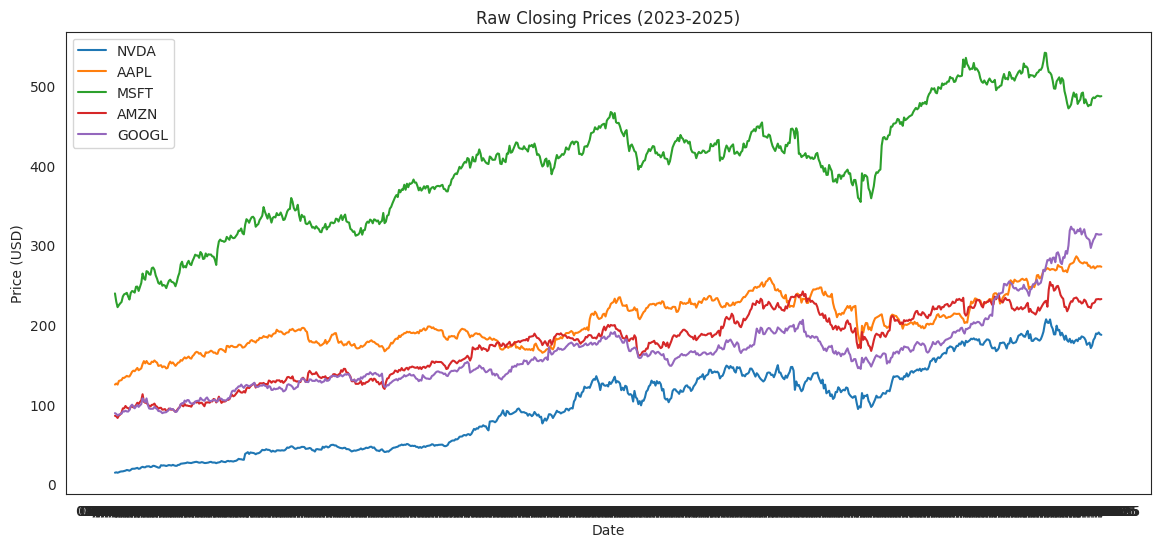

In [ ]:
# Plot closing prices for top 5 tickers
top_5_tickers = df_stock['Stock Name'].unique()[:5]

plt.figure(figsize=(14, 6))
for ticker in top_5_tickers:
    subset = df_stock[df_stock['Stock Name'] == ticker]
    plt.plot(subset['Date'], subset['Close'], label=ticker)

plt.title('Raw Closing Prices (2023-2025)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

/tmp/ipykernel_3015/1833813185.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_volume.values, y=sector_volume.index, palette='magma')


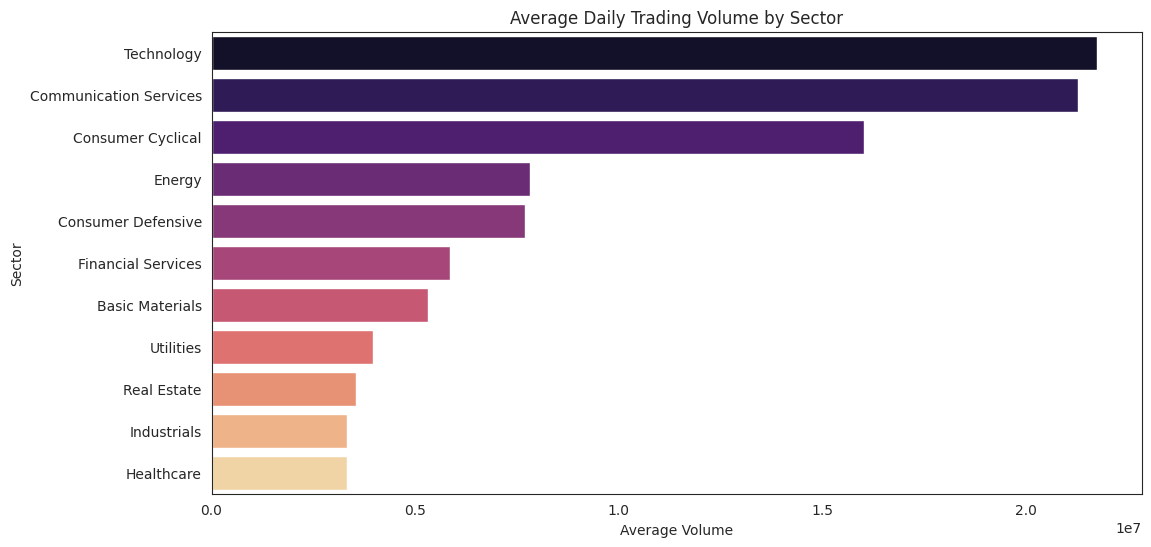

In [ ]:
# Average daily volume per sector
sector_volume = df_stock.groupby('Sector')['Volume'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=sector_volume.values, y=sector_volume.index, palette='magma')
plt.title('Average Daily Trading Volume by Sector')
plt.xlabel('Average Volume')
plt.ylabel('Sector')
plt.show()

In [ ]:
numerical_cols = df_stock.select_dtypes(include=['number']).columns
df_stock[numerical_cols].corr()

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.999920,0.999913,0.999835,0.999699,-0.104307
High,0.999920,1.000000,0.999890,0.999923,0.999799,-0.103717
Low,0.999913,0.999890,1.000000,0.999926,0.999776,-0.104946
Close,0.999835,0.999923,0.999926,1.000000,0.999864,-0.104300
Adj Close,0.999699,0.999799,0.999776,0.999864,1.000000,-0.101977
Volume,-0.104307,-0.103717,-0.104946,-0.104300,-0.101977,1.000000


#### From the above corelation we see that the numerical columns are highly corelated except volume column so we need to do feature engineer

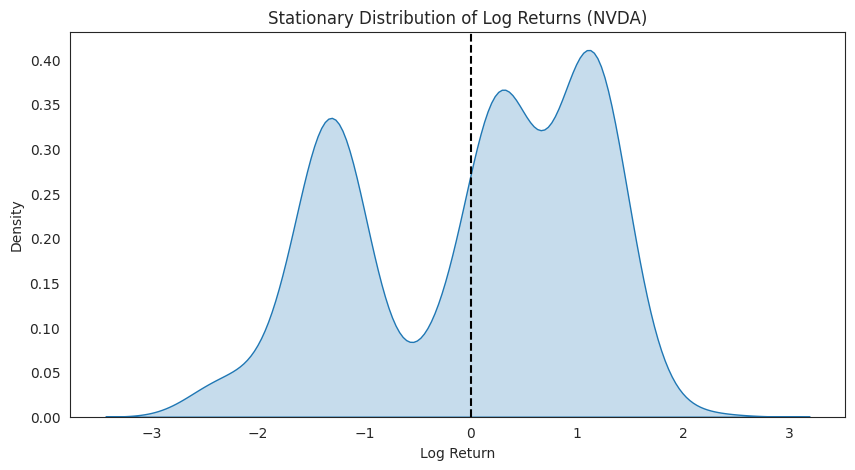

In [ ]:
import numpy as np
# Ensure data is sorted by date before shifting
df_stock = df_stock.sort_values(by=['Stock Name', 'Date'])

# Calculate daily log returns using Adj Close
df_stock['Log_Return'] = df_stock.groupby('Stock Name')['Adj Close'].transform(lambda x: np.log(x / x.shift(1)))

# Drop the first day (which becomes NaN after the shift)
df_stock = df_stock.dropna(subset=['Log_Return'])

# Plot the distribution to prove stationarity
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_stock[df_stock['Stock Name'] == top_5_tickers[0]]['Log_Return'], fill=True)
plt.title(f'Stationary Distribution of Log Returns ({top_5_tickers[0]})')
plt.xlabel('Log Return')
plt.axvline(0, color='black', linestyle='--')
plt.show()

In [ ]:
numerical_cols = df_stock.select_dtypes(include=['number']).columns
df_stock[numerical_cols].corr()

,Open,High,Low,Close,Adj Close,Volume,Log_Return
Open,1.000000,0.999920,0.999912,0.999835,0.999699,-0.104322,0.126067
High,0.999920,1.000000,0.999890,0.999923,0.999799,-0.103733,0.126230
Low,0.999912,0.999890,1.000000,0.999926,0.999777,-0.104962,0.125786
Close,0.999835,0.999923,0.999926,1.000000,0.999864,-0.104318,0.126144
Adj Close,0.999699,0.999799,0.999777,0.999864,1.000000,-0.101996,0.127470
Volume,-0.104322,-0.103733,-0.104962,-0.104318,-0.101996,1.000000,-0.038330
Log_Return,0.126067,0.126230,0.125786,0.126144,0.127470,-0.038330,1.000000


#### We can see that the log return is not corelated with other variables so we can drop the columns which are highly corelated.

In [ ]:
df_stock.drop(columns=['Open','High','Low','Close','Adj Close'],inplace= True)

In [ ]:
df_stock.head()

,Date,Volume,Stock Name,Sector,Log_Return
119371,01/02/2024,862000,A,Healthcare,-0.148359
119139,01/03/2023,3132800,A,Healthcare,0.025732
119391,01/03/2024,1531000,A,Healthcare,0.018448
119411,01/04/2024,968300,A,Healthcare,0.047306
119662,01/04/2025,2302800,A,Healthcare,-0.236538


In [ ]:
merged_df = pd.merge(
    df_news,
    df_stock,
    left_on=['Date','Stock Name'],
    right_on=['Date','Stock Name'],
    how='inner'# Need to change to right after news eda is completed
)
# Display top 5 in the merged dataset
merged_df.head()

,Date,Tweet,Stock Name,Company Name,Embeddings,Volume,Sector,Log_Return
0,01/08/2025,5 Best Dividend Stocks To Buy For August 2025 ...,PNC,"The PNC Financial Services Group, Inc.","[-5.0920433e-05, -0.04448494, -0.001520699, 0....",2639400,Financial Services,0.090236
1,01/08/2025,"Waste Management, Inc. (WM)’s CEO Is Doing A “...",WM,"Waste Management, Inc.","[-0.009468835, -0.045025613, -0.014149481, -0....",1389500,Industrials,0.119116
2,01/08/2025,"FedEx Corporation (FDX)’s CEO Is A “Hitter,” S...",FDX,FedEx Corporation,"[-0.022724079, -0.036048323, -0.010419616, 0.0...",2213900,Industrials,-0.294463
3,01/08/2025,"Exxon, Chevron Surpass Estimates With Record O...",XOM,Exxon Mobil Corporation,"[-0.011347536, -0.042125393, 0.015024937, -0.0...",19652000,Energy,-0.030269
4,01/08/2025,KLA Corp (KLAC) Q4 2025 Earnings Call Highligh...,KLAC,KLA Corporation,"[0.025778862, -0.071486175, 0.016954936, -0.02...",1474600,Technology,0.168472


In [ ]:
merged_df.drop(columns=['Tweet'], inplace=True)

In [ ]:
merged_df.isnull().sum()

,0
Date,0
Stock Name,0
Company Name,0
Embeddings,0
Volume,0
Sector,0
Log_Return,0


In [ ]:
merged_df.shape

(64067, 7)

### Exporting merged file and displaying the progress bar

In [ ]:
import numpy as np
from tqdm.notebook import tqdm

merged_df.shape

# Define the output file path
output_csv_path = "merged_data.csv"

# Calculate the total number of rows
total_rows = len(merged_df)

# Define a chunk size (e.g., 10,000 rows per chunk) to update the progress bar
# Adjust this based on your DataFrame size and desired granularity of progress updates
chunk_size = 10000

# Initialize tqdm progress bar
with tqdm(total=total_rows, unit='rows', desc=f'Exporting to {output_csv_path}') as pbar:
    # Write the header first
    merged_df.head(0).to_csv(output_csv_path, index=False, mode='w', header=True)

    # Iterate over the DataFrame in chunks and append to the CSV
    for i in range(0, total_rows, chunk_size):
        chunk = merged_df.iloc[i:i + chunk_size]
        chunk.to_csv(output_csv_path, index=False, mode='a', header=False)
        pbar.update(len(chunk))

print(f"Successfully exported {total_rows} rows to {output_csv_path}")

## Model Training

### Adding Libs required

In [ ]:
%pip install -q numpy pandas torch gym stable-baselines3 scikit-learn ta shimmy

### Define seeding

In [ ]:
# Set random seeds for reproducibility
import os
import random
import numpy as np
import torch

SEED = 42

# Python's built-in random module
random.seed(SEED)

# NumPy random seed
np.random.seed(SEED)

# PyTorch seeds
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Set PyTorch to use deterministic algorithms (slightly slower but reproducible)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Set environment variable for other libraries
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"Random seeds set to {SEED} for reproducibility")

### Helper functions

In [ ]:
import numpy as np

def add_features(df):
    # CRITICAL: Group by stock to prevent shifts from bleeding across tickers
    # Use transform() to keep results aligned with original dataframe
    df = df.sort_values(["Stock Name", "Date"]).reset_index(drop=True)

    # === TEMPORAL FIX: Shift Volume to previous day ===
    # In real trading, today's volume is unknown until market close
    # Use yesterday's volume as a feature (information available at decision time)
    df["Volume"] = df.groupby("Stock Name")["Volume"].transform(lambda x: x.shift(1))

    # Shifted returns (yesterday's return)
    df["Return_1"] = df.groupby("Stock Name")["Log_Return"].transform(lambda x: x.shift(1))

    # Rolling sums (simpler approach using transform + rolling)
    df["Return_5"] = df.groupby("Stock Name")["Log_Return"].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).sum()
    )
    df["Return_10"] = df.groupby("Stock Name")["Log_Return"].transform(
        lambda x: x.shift(1).rolling(10, min_periods=1).sum()
    )

    df["Trend"] = np.where(df["Return_5"] > 0, 1, -1)

    # Drop only rows with NaN in computed feature columns (preserve rows where possible)
    # Include Volume_prev in NaN check since it creates NaN on first row per stock
    df = df.dropna(subset=["Volume", "Return_1", "Return_5", "Return_10", "Trend"]).reset_index(drop=True)
    return df

def aggregate_and_shift_embeddings(df):
    """
    Aggregate embeddings per (Stock Name, Date) by taking the mean,
    then shift to previous day. Prevents leakage without dropping rows.
    """
    # Group by Stock Name and Date, aggregate embeddings (mean)
    # Each row in original df can have multiple embeddings per day
    daily_embeddings = df.groupby(['Stock Name', 'Date'])['Embeddings'].apply(
        lambda x: np.mean([emb for emb in x if emb is not None], axis=0) if any(e is not None for e in x) else None
    ).reset_index()
    daily_embeddings.columns = ['Stock Name', 'Date', 'daily_embedding']

    # Shift daily embeddings to get previous day's aggregated embedding
    # CRITICAL: Must shift WITHIN each stock group to prevent cross-ticker leakage
    daily_embeddings['prev_daily_embedding'] = daily_embeddings.groupby('Stock Name')['daily_embedding'].shift(1)

    # Merge back: each row in df gets the aggregated embedding from previous day
    df = df.merge(
        daily_embeddings[['Stock Name', 'Date', 'prev_daily_embedding']],
        on=['Stock Name', 'Date'],
        how='left'
    )

    # Replace embeddings with shifted daily aggregates
    df['Embeddings'] = df['prev_daily_embedding']
    df = df.drop(columns=['prev_daily_embedding'])

    # Remove rows where no previous-day embedding exists (first row per stock)
    df = df.dropna(subset=['Embeddings']).reset_index(drop=True)

    return df

### Defining RL code

In [ ]:
import re
import gym
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from gym import spaces
from sklearn.preprocessing import StandardScaler
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

# =========================
# EMBEDDING PARSER
# =========================
def parse_embedding(x):
    if not isinstance(x, str):
        return None

    x = x.replace("[", "").replace("]", "").replace('"', "").replace("'", "").strip()
    numbers = re.findall(r"[-+]?\d*\.\d+e[-+]?\d+|[-+]?\d*\.\d+|[-+]?\d+", x)

    if len(numbers) == 0:
        return None

    return np.array([float(n) for n in numbers], dtype=np.float32)

# =========================
# LOADING DATA
# =========================
def load_data(path):
    df = pd.read_csv(path, engine="python", on_bad_lines="skip")

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).reset_index(drop=True)

    df["Embeddings"] = df["Embeddings"].apply(parse_embedding)
    df = df.dropna(subset=["Embeddings"]).reset_index(drop=True)

    # Ensure same embedding size
    emb_dim = df["Embeddings"].apply(len).mode()[0]
    df = df[df["Embeddings"].apply(lambda x: len(x) == emb_dim)].reset_index(drop=True)

    return df, emb_dim



def normalize_fit(df, cols):
    """Fit scaler on training data and transform. Returns dataframe and scaler.

    NOTE: Do NOT include categorical features (e.g., Sector_Encoded).
    Only scale numerical features (Volume, Return_1, Return_5, Return_10).
    Trend is ordinal (1 or -1) and can be scaled or left raw.
    """
    scaler = StandardScaler()
    df = df.copy()
    df[cols] = scaler.fit_transform(df[cols])
    return df, scaler

def normalize_transform(df, cols, scaler):
    """Apply pre-fitted scaler to data (for test/inference). Prevents data leakage."""
    df = df.copy()
    df[cols] = scaler.transform(df[cols])
    return df

# =========================
# ENVIRONMENT
# =========================
class TradingEnv(gym.Env):
    def __init__(self, df, feature_cols, emb_dim):
        super().__init__()

        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.emb_dim = emb_dim

        self.current_step = 0
        self.position = 0

        obs_dim = len(feature_cols) + emb_dim

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32
        )

        self.action_space = spaces.Discrete(3)  # HOLD, BUY, SELL

    def reset(self):
        self.current_step = 0
        self.position = 0
        return self._get_obs()

    def _get_obs(self):
        row = self.df.iloc[self.current_step]
        features = row[self.feature_cols].values.astype(np.float32)
        embedding = row["Embeddings"].astype(np.float32)
        return np.concatenate([features, embedding])

    def step(self, action):
        row = self.df.iloc[self.current_step]
        log_ret = row["Log_Return"]

        reward = 0

        # Dense reward
        if self.position == 1:
            reward += log_ret

        if action == 1:  # BUY
            self.position = 1
        elif action == 2:  # SELL
            self.position = 0

        self.current_step += 1
        done = self.current_step >= len(self.df) - 1

        return self._get_obs(), reward, done, {}

# =========================
# FEATURE EXTRACTOR
# =========================
class MultiModalExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=256):
        super().__init__(observation_space, features_dim)

        self.net = nn.Sequential(
            nn.Linear(observation_space.shape[0], 512),
            nn.ReLU(),
            nn.Linear(512, features_dim),
            nn.ReLU()
        )

    def forward(self, obs):
        return self.net(obs)

# =========================
# TRAIN
# =========================

def train(data_path):
    df, emb_dim = load_data(data_path)

    # VALIDATION: Ensure features exist (they should be pre-computed during data prep)
    required_features = ["Sector_Encoded", "Volume", "Return_1", "Return_5", "Return_10", "Trend"]
    missing_features = [f for f in required_features if f not in df.columns]
    if missing_features:
        raise ValueError(f"Missing features in data: {missing_features}. "
                        f"Run data preparation cells first to compute features.")

    # All features (categorical + numerical) used by environment
    all_feature_cols = [
        "Sector_Encoded",        # Categorical: sector label (do NOT scale)
        "Volume",                # Numerical: LAGGED to previous day (no lookahead bias)
        "Return_1",              # Numerical: yesterday's return
        "Return_5",              # Numerical: past 5-day return
        "Return_10",             # Numerical: past 10-day return
        "Trend"                  # Ordinal: +1 or -1 (can be scaled or raw)
    ]

    # Numerical features to standardize (categorical Sector_Encoded excluded)
    numerical_feature_cols = ["Volume", "Return_1", "Return_5", "Return_10", "Trend"]

    # FIT scaler on training numerical features only (exclude categorical Sector_Encoded)
    df, scaler = normalize_fit(df, numerical_feature_cols)

    env = TradingEnv(df, all_feature_cols, emb_dim)

    policy_kwargs = dict(
        features_extractor_class=MultiModalExtractor,
        features_extractor_kwargs=dict(features_dim=256),
    )

    model = PPO(
        "MlpPolicy",
        env,
        policy_kwargs=policy_kwargs,
        verbose=1,
        learning_rate=1e-4,
        batch_size=128,
        gamma=0.99,
        n_steps=2048,
        seed=42,
    )

    # INCREASED TIMESTEPS for better stability (from 50k to 300k)
    model.learn(total_timesteps=300000)
    model.save("ppo_trading_agent")

    return model, env, df, all_feature_cols, scaler

#=========================
# INFERENCE
# =========================
def predict(model, env, df, output_csv="final_predictions.csv"):
    obs = env.reset()
    done = False

    action_map = {0: "HOLD", 1: "BUY", 2: "SELL"}
    records = []

    step = 0

    while not done:
        # Get action from model
        action, _ = model.predict(obs)
        action = int(action)

        # Step environment
        obs, reward, done, _ = env.step(action)

        # Get current row data
        row = df.iloc[min(env.current_step, len(df) - 1)]

        # Determine price trend
        trend = "UP" if row["Log_Return"] > 0 else "DOWN" if row["Log_Return"] < 0 else "NEUTRAL"

        # Get sector value
        sector_value = row['Sector_Encoded'] if 'Sector_Encoded' in row else 'N/A'

        # Append record
        records.append({
            "step": step,
            "date": row["Date"],
            "stock_ticker": row["Stock Name"],
            "company_name": row["Company Name"],
            "sector": sector_value,
            "log_return": row["Log_Return"],
            "price_trend": trend,
            "action": action_map[action],
            "reward": reward
        })

        step += 1

    # Create and save results
    results_df = pd.DataFrame(records)
    results_df.to_csv(output_csv, index=False)
    print(f"Saved to {output_csv}")

### Prepare data: add features and shift embeddings

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

DATA_PATH = 'merged_data.csv'

# Load raw data (WITHOUT feature engineering - will add after split)
initial_df, emb_dim = load_data(DATA_PATH)

# Sort by date for proper shifting
initial_df['Date'] = pd.to_datetime(initial_df['Date'])
initial_df = initial_df.sort_values(by=['Stock Name', 'Date']).reset_index(drop=True)

# Save pre-split, pre-feature-engineering data
output_filename_temp = "prepared_data_before_split.csv"
initial_df.to_csv(output_filename_temp, index=False)
print(f"Raw data (sorted by date, ready for split) saved to {output_filename_temp}")
display(initial_df.head())

### Split data and label encode
###### Fit encoder ONLY on training data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import re # Import re for parse_embedding function

# =========================
# EMBEDDING PARSER (copied for self-containment)
# =========================
def parse_embedding(x):
    if not isinstance(x, str):
        return None

    x = x.replace("[", "").replace("]", "").replace('"', "").replace("'", "").strip()
    numbers = re.findall(r"[-+]?\d*\.\d+e[-+]?\d+|[-+]?\d*\.\d+|[-+]?\d+", x)

    if len(numbers) == 0:
        return None

    return np.array([float(n) for n in numbers], dtype=np.float32)

# Load prepared data (raw, unsplit)
df_prepared = pd.read_csv('prepared_data_before_split.csv')
df_prepared['Date'] = pd.to_datetime(df_prepared['Date'])

# Re-parse embeddings after loading from CSV
# This is crucial because saving to CSV converts numpy arrays to strings
df_prepared["Embeddings"] = df_prepared["Embeddings"].apply(parse_embedding)
df_prepared = df_prepared.dropna(subset=["Embeddings"]).reset_index(drop=True)

# Determine embedding dimension and filter inconsistent rows, if any
if not df_prepared.empty:
    # Assuming all embeddings should have the same dimension as initially determined
    # The emb_dim from initial_df (from load_data) would be appropriate here
    # For robustness, we re-calculate it from df_prepared itself.
    emb_dim_current = df_prepared["Embeddings"].apply(len).mode()[0]
    df_prepared = df_prepared[df_prepared["Embeddings"].apply(lambda x: len(x) == emb_dim_current)].reset_index(drop=True)
else:
    raise ValueError("No data left after parsing embeddings.")

# SPLIT into train and test FIRST
train_df = df_prepared[(df_prepared['Date'].dt.year >= 2023) & (df_prepared['Date'].dt.year <= 2024)].copy()
test_df = df_prepared[df_prepared['Date'].dt.year == 2025].copy()

# Ensure data is sorted by Stock Name and Date (critical for shift to work correctly)
train_df = train_df.sort_values(['Stock Name', 'Date']).reset_index(drop=True)
test_df = test_df.sort_values(['Stock Name', 'Date']).reset_index(drop=True)

# Aggregate embeddings per day BEFORE shifting
# This preserves all rows while preventing same-day leakage
# (aggregate_and_shift_embeddings function is defined in helper functions cell)

print("Aggregating embeddings by day (mean) and shifting...")
train_df = aggregate_and_shift_embeddings(train_df)
test_df = aggregate_and_shift_embeddings(test_df)

print(f"Training data rows: {len(train_df)} (aggregated embeddings)")
print(f"Testing data rows: {len(test_df)} (aggregated embeddings)")

# Remove rows with NaN embeddings (from first row of each stock per split)
train_df = train_df.dropna(subset=['Embeddings']).reset_index(drop=True)
test_df = test_df.dropna(subset=['Embeddings']).reset_index(drop=True)

# NOTE: Embeddings are already aggregated as numpy arrays, no need to parse again

# ADD FEATURES AFTER SPLIT (prevents distribution shift from mixing train/test in feature computation)
# IMPORTANT: add_features() now includes temporal fixes:
#   - Volume is shifted to previous day (no lookahead bias)
#   - Returns and rolling windows use only past data (shift(1))
#   - Embeddings are lagged to previous day
train_df = add_features(train_df)
test_df = add_features(test_df)

# FIT label encoder ONLY on training data sectors
label_encoder = LabelEncoder()
train_df['Sector_Encoded'] = label_encoder.fit_transform(train_df['Sector'])
train_df = train_df.drop(columns=['Sector'])

# SAFETY CHECK: Verify all test sectors were seen during training
unseen_sectors = set(test_df['Sector']) - set(label_encoder.classes_)
if unseen_sectors:
    print(f"Test data contains unseen sectors: {unseen_sectors}")
    print(f"             encoder.transform() will fail on these sectors!")
    raise ValueError(f"Test data has sectors not in training: {unseen_sectors}")
else:
    print(f"All test sectors exist in training data")

# APPLY the same fitted encoder to test data (prevents encoder leakage)
test_df['Sector_Encoded'] = label_encoder.transform(test_df['Sector'])
test_df = test_df.drop(columns=['Sector'])

# Save processed files
train_df.to_csv('train_data_2023_2024.csv', index=False)
test_df.to_csv('test_data_2025.csv', index=False)

print(f" Embeddings shifted separately per split (perfect temporal isolation)")
print(f"Same-day leakage prevented: embeddings now guaranteed from previous day")
print(f"Volume lagged to previous day (no lookahead bias)")
print(f"Features computed separately for each split (no distribution shift)")
print(f"Feature shifts properly grouped by stock (no cross-ticker bleed)")
print(f"Label encoder fitted on 2023-2024 training data only")

print("\nTraining Data Head:")
display(train_df.head())

print(f"Training data (2023-2024) saved to train_data_2023_2024.csv")

print("\nTesting Data Head:")
display(test_df.head())

print(f"Testing data (2025) saved to test_data_2025.csv")

print(f"\nSector mapping (from training data): {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

### Running RL agent in train and test env

In [ ]:
# =========================
# MAIN FUNCTION
# =========================
if __name__ == "__main__":
    # --- Training Phase ---
    TRAIN_DATA_PATH = "train_data_2023_2024.csv"
    model, _, _, all_feature_cols, scaler = train(TRAIN_DATA_PATH) # Get model, feature_cols, AND scaler from training

    # --- Inference Phase ---
    # Load and prepare test data
    TEST_DATA_PATH = "test_data_2025.csv"
    test_df_raw, emb_dim = load_data(TEST_DATA_PATH) # Load raw test data (features already added during prep)
    # CRITICAL: Use the scaler from training (prevents data leakage)
    test_df_normalized = normalize_transform(test_df_raw.copy(), ["Volume", "Return_1", "Return_5", "Return_10", "Trend"], scaler) # Normalize test data with training scaler

    # Create a new environment for prediction using the test data
    test_env = TradingEnv(test_df_normalized, all_feature_cols, emb_dim)

    print("\n=== RUNNING INFERENCE ON 2025 DATA ===\n")
    print("Note: Using scaler fitted on training data to prevent data leakage")
    predict(model, test_env, test_df_raw, output_csv="predictions_2025.csv")

### Merging actual and predicted data for evaluation

In [ ]:
import pandas as pd

actual_data_2025 = pd.read_csv('test_data_2025.csv')
predicted_data_2025 = pd.read_csv('predictions_2025.csv')

actual_data_2025['Date'] = pd.to_datetime(actual_data_2025['Date'])
predicted_data_2025['date'] = pd.to_datetime(predicted_data_2025['date'])

# === FIX: AGGREGATE PREDICTIONS BY DATE TO ELIMINATE DUPLICATES ===
# Multiple news articles per day create duplicate prediction rows
# Solution: Take the MAJORITY action for each stock+date combination
def get_majority_action(actions):
    """Return the most common action for a given stock+date."""
    return actions.value_counts().idxmax()

# Group predictions by date, stock, and company
# Aggregate using majority voting on actions and mean on rewards
predicted_daily = predicted_data_2025.groupby(['date', 'stock_ticker', 'company_name']).agg({
    'action': get_majority_action,
    'reward': 'mean',
    'log_return': 'first'  # Same for all rows in the group
}).reset_index()

# Rename for consistency
predicted_daily = predicted_daily.rename(columns={'date': 'Date'})

# Now merge with actual data (which is already at daily level)
merged_results = pd.merge(
    predicted_daily[['Date', 'stock_ticker', 'company_name', 'action', 'reward', 'log_return']],
    actual_data_2025[['Date', 'Stock Name', 'Company Name', 'Log_Return']],
    left_on=['Date', 'stock_ticker', 'company_name'],
    right_on=['Date', 'Stock Name', 'Company Name'],
    how='inner'  # Use inner join to ensure only matching records
)

# Use actual log return (from data, not prediction)
merged_results = merged_results.drop(columns=['log_return'])
merged_results = merged_results.rename(columns={'Log_Return': 'actual_log_return'})

print("Comparison of Predicted Actions and Actual Log Returns for 2025 Test Data (Daily Aggregated):")
print(f"Number of unique stock-date combinations: {len(merged_results)}")
print("\nFirst 10 rows:")
display(merged_results.head(10))

## Evaluation

### Checking and visualizing accuracy

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

log_return_threshold = 0.005

# Evaluate correctness: does the predicted action match the actual price movement?
merged_results['is_correct'] = False

# BUY is correct if price goes up (positive log return)
merged_results.loc[
    (merged_results['action'] == 'BUY') & (merged_results['actual_log_return'] > 0),
    'is_correct'
] = True

# SELL is correct if price goes down (negative log return)
merged_results.loc[
    (merged_results['action'] == 'SELL') & (merged_results['actual_log_return'] < 0),
    'is_correct'
] = True

# HOLD is correct if price movement is small (within threshold)
merged_results.loc[
    (merged_results['action'] == 'HOLD')
    & (merged_results['actual_log_return'].abs() <= log_return_threshold),
    'is_correct'
] = True

# Calculate overall and per-action accuracy
overall_accuracy = merged_results['is_correct'].mean() * 100
print(f"Overall Prediction Accuracy (Daily Aggregated): {overall_accuracy:.2f}%")
print(f"Total daily predictions evaluated: {len(merged_results)}")

accuracy_by_action = (
    merged_results.groupby('action')['is_correct'].mean() * 100
).reset_index()
accuracy_by_action.columns = ['Action', 'Accuracy_Percentage']
accuracy_by_action['Sample_Count'] = merged_results.groupby('action').size().values

print("\nAccuracy by Action Type:")
display(accuracy_by_action)

In [ ]:
# Visualize accuracy per action type
plt.figure(figsize=(8, 6))
sns.barplot(x='Action', y='Accuracy_Percentage', data=accuracy_by_action, palette='viridis')
plt.title('Prediction Accuracy by Action Type')
plt.xlabel('Action')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100) # Ensure y-axis is from 0 to 100
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualize the overall accuracy as a single bar or text
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Overall'], [overall_accuracy], color='skyblue')
ax.set_ylim(0, 100)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Overall Prediction Accuracy')

# Add the percentage value on top of the bar
ax.text(
    'Overall', overall_accuracy + 2,
    f'{overall_accuracy:.2f}%',
    ha='center', va='bottom'
)
plt.show()


In [5]:
import os
import json

# Type the exact name of the file you uploaded to the sidebar
filename = "/content/drive/MyDrive/Colab Notebooks/Data_Mining_Latest_Code_with_proper_seeding_and_evaluation.ipynb"

# Load the notebook
with open(filename, 'r', encoding='utf-8') as f:
    nb = json.load(f)

# Remove the problematic widgets metadata
if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']
    print("Success: Widget metadata removed!")
else:
    print("No widget metadata found in this file.")

# Save the cleaned notebook
# Correctly construct the fixed_filename path
dirname = os.path.dirname(filename)
basename = os.path.basename(filename)
name, ext = os.path.splitext(basename)
fixed_basename = f"{name}_FIXED{ext}"
fixed_filename = os.path.join(dirname, fixed_basename)

with open(fixed_filename, 'w', encoding='utf-8') as f:
    json.dump(nb, f, indent=2)

print(f"Saved! You can now download {fixed_filename} from the sidebar and upload it to GitHub.")

Success: Widget metadata removed!
Saved! You can now download /content/drive/MyDrive/Colab Notebooks/Data_Mining_Latest_Code_with_proper_seeding_and_evaluation_FIXED.ipynb from the sidebar and upload it to GitHub.
